In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
# 1. Load the data
df = pd.read_csv('../results/all_experiments.csv')

# 1. Optimal Params for SimpleCNN

In [3]:
df[(df["experiment_name"].str.contains("dropout")) | (df["experiment_name"] == "baseline_simple_cnn")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
24,2026-04-21T02:39:46.683263,baseline_simple_cnn,simple_cnn,adamw,0.001,128,0.30,none,he,0.9191,...,116.69,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,baseline_simple_cnn.yaml,11980596
9,2026-04-21T02:09:24.965559,ablation_dropout_04,simple_cnn,adamw,0.001,128,0.40,none,he,0.9171,...,108.84,28,23,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_dropout_04.yaml,11980581
8,2026-04-21T02:06:59.055394,ablation_dropout_025,simple_cnn,adamw,0.001,128,0.25,none,he,0.9117,...,107.84,28,23,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_dropout_025.yaml,11980580
7,2026-04-21T02:04:26.225567,ablation_dropout_00,simple_cnn,adamw,0.001,128,0.00,none,he,0.9114,...,93.28,24,19,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_dropout_00.yaml,11980579
11,2026-04-21T02:11:54.936376,ablation_dropout_05,simple_cnn,adamw,0.001,128,0.50,none,he,0.9108,...,110.15,30,25,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_dropout_05.yaml,11980582


In [4]:
df[df["experiment_name"].str.contains("lr")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
14,2026-04-21T02:16:20.046640,ablation_lr_0001,simple_cnn,adamw,0.0010,128,0.3,none,he,0.9191,...,116.54,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_lr_0001.yaml,11980587
16,2026-04-21T02:17:47.031383,ablation_lr_001,simple_cnn,adamw,0.0100,128,0.3,none,he,0.9028,...,54.36,14,9,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_lr_001.yaml,11980588
15,2026-04-21T02:17:30.486231,ablation_lr_00001,simple_cnn,adamw,0.0001,128,0.3,none,he,0.8996,...,186.08,50,50,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_lr_00001.yaml,11980586
17,2026-04-21T02:19:40.269426,ablation_lr_01,simple_cnn,adamw,0.1000,128,0.3,none,he,0.6595,...,50.44,13,8,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_lr_01.yaml,11980589


In [5]:
df[(df["experiment_name"].str.contains("augmentation")) | (df["experiment_name"] == "baseline_simple_cnn")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
24,2026-04-21T02:39:46.683263,baseline_simple_cnn,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,116.69,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,baseline_simple_cnn.yaml,11980596
2,2026-04-21T01:41:01.180075,ablation_augmentation_none,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,117.91,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_augmentation_none.yaml,11980574
1,2026-04-21T01:38:15.544820,ablation_augmentation_hflip,simple_cnn,adamw,0.001,128,0.3,hflip,he,0.9176,...,160.66,38,33,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_augmentation_hflip.yaml,11980573
0,2026-04-21T01:35:02.124927,ablation_augmentation_crop_flip,simple_cnn,adamw,0.001,128,0.3,crop_flip,he,0.9070,...,238.47,50,50,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_augmentation_crop_flip.yaml,11980572


In [6]:
df[df["experiment_name"].str.contains("batch_size")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
3,2026-04-21T01:41:27.947499,ablation_batch_size_128,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,107.86,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_batch_size_128.yaml,11980575
6,2026-04-21T02:01:50.828457,ablation_batch_size_64,simple_cnn,adamw,0.001,64,0.3,none,he,0.9180,...,106.76,21,16,207018,1293312,45.7,NVIDIA A100-SXM4-80GB,42,ablation_batch_size_64.yaml,11980578
5,2026-04-21T01:59:19.719530,ablation_batch_size_32,simple_cnn,adamw,0.001,32,0.3,none,he,0.9170,...,151.89,23,18,207018,1293312,45.7,NVIDIA A100-SXM4-80GB,42,ablation_batch_size_32.yaml,11980577
4,2026-04-21T01:43:31.121645,ablation_batch_size_256,simple_cnn,adamw,0.001,256,0.3,none,he,0.9145,...,85.08,28,23,207018,1293312,79.4,NVIDIA A100-SXM4-80GB,42,ablation_batch_size_256.yaml,11980576


In [7]:
df[df["experiment_name"].str.contains("initialization")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
13,2026-04-21T02:13:45.706508,ablation_initialization_he,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,115.10,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_initialization_he.yaml,11980584
10,2026-04-21T02:11:01.891202,ablation_initialization_default,simple_cnn,adamw,0.001,128,0.3,none,default,0.9182,...,59.17,15,10,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_initialization_default.yaml,11980583
12,2026-04-21T02:13:27.520313,ablation_initialization_xavier,simple_cnn,adamw,0.001,128,0.3,none,xavier,0.9160,...,58.95,16,11,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_initialization_xavier.yaml,11980585


In [8]:
df[df["experiment_name"].str.contains("optimizer")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
18,2026-04-21T02:22:42.443616,ablation_optimizer_adamw,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,115.09,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_optimizer_adamw.yaml,11980590
19,2026-04-21T02:25:24.839460,ablation_optimizer_adam,simple_cnn,adam,0.001,128,0.3,none,he,0.9178,...,128.96,33,28,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,ablation_optimizer_adam.yaml,11980591
20,2026-04-21T02:29:29.018354,ablation_optimizer_sgd_momentum,simple_cnn,sgd_momentum,0.001,128,0.3,none,he,0.8915,...,189.52,50,49,207018,1293312,49.3,NVIDIA A100-SXM4-80GB,42,ablation_optimizer_sgd_momentum.yaml,11980592
21,2026-04-21T02:33:30.188963,ablation_optimizer_sgd,simple_cnn,sgd,0.001,128,0.3,none,he,0.8483,...,187.31,50,50,207018,1293312,48.5,NVIDIA A100-SXM4-80GB,42,ablation_optimizer_sgd.yaml,11980593


In [9]:
df[(df["experiment_name"].str.contains("dataeff")) & (df["model_type"] == "simple_cnn")].sort_values(by="accuracy", ascending=False)

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,train_time_sec,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id
32,2026-04-21T06:55:38.931635,dataeff_simple_cnn_50k,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,103.98,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,dataeff_simple_cnn_50k.yaml,11980604
30,2026-04-21T02:48:19.089225,dataeff_simple_cnn_10k,simple_cnn,adamw,0.001,128,0.3,none,he,0.8710,...,39.60,28,23,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,dataeff_simple_cnn_10k.yaml,11980602
33,2026-04-21T06:57:17.430289,dataeff_simple_cnn_5k,simple_cnn,adamw,0.001,128,0.3,none,he,0.8588,...,44.13,42,37,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,dataeff_simple_cnn_5k.yaml,11980605
31,2026-04-21T02:49:22.926790,dataeff_simple_cnn_1k,simple_cnn,adamw,0.001,128,0.3,none,he,0.7695,...,29.08,31,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,dataeff_simple_cnn_1k.yaml,11980603


Optimal parameters for Simple CNN: 
- Training size: 50k
- Augmentation: None
- Optimizer: adamw
- Learning Rate: 0.001
- Batch Size: 128
- Dropout: 0.3
- Initialization: he

# 2. Accuracy vs Dataset Size

Hypothesis: CNN pulls ahead at N>10000 once spatial priors become useful.

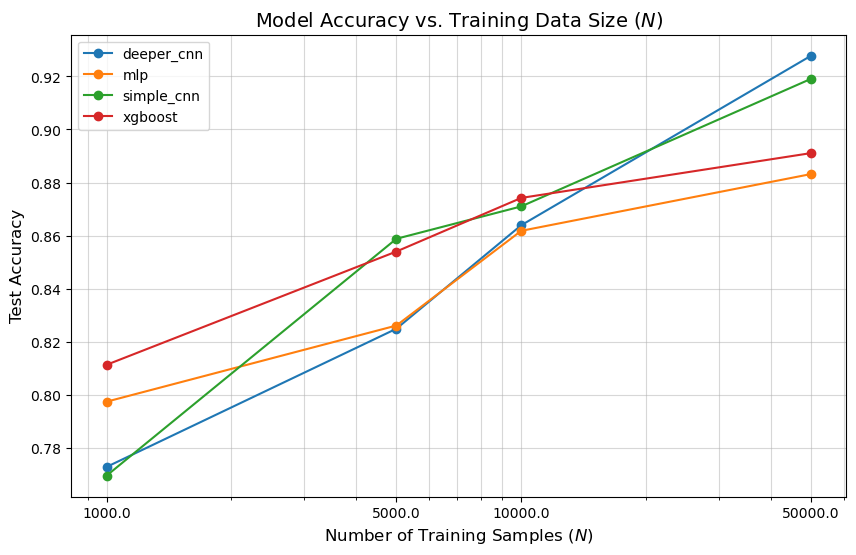

In [10]:
# 2. Extract N from the experiment_name (e.g., 'dataeff_simple_cnn_10k' -> 10000)
def extract_n(name):
    match = re.search(r'(\d+)k', name)
    return int(match.group(1)) * 1000 if match else None

df['N'] = df['experiment_name'].apply(extract_n)

# 3. Clean up: Pivot the data so we have N as index and models as columns
# This handles cases where you might have multiple runs for the same N
plot_df = df.pivot_table(index='N', columns='model_type', values='accuracy')

# 4. Plotting
plt.figure(figsize=(10, 6))
for model in plot_df.columns:
    plt.plot(plot_df.index, plot_df[model], marker='o', label=model)

plt.title('Model Accuracy vs. Training Data Size ($N$)', fontsize=14)
plt.xlabel('Number of Training Samples ($N$)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xscale('log') # Recommended since N jumps from 1k to 50k
plt.xticks(plot_df.index, labels=[str(i) for i in plot_df.index])
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

# 3. Accuracy vs FLOPs

In [11]:
baselines = df[(df["experiment_name"].str.contains("baseline") & (~df["experiment_name"].str.contains("xgboost")))].sort_values(by="accuracy")
baselines

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id,N
23,2026-04-21T02:37:02.219750,baseline_mlp,mlp,adamw,0.001,128,0.3,none,he,0.8832,...,19,14,535818,535040,28.6,NVIDIA A100-SXM4-80GB,42,baseline_mlp.yaml,11980595,NaN
38,2026-05-06T20:15:56.897467,baseline_resnet18,resnet18,adamw,0.001,128,0.3,none,he,0.9108,...,19,14,11175370,33184000,242.2,NVIDIA A100-SXM4-80GB,42,baseline_resnet18.yaml,12609947,NaN
24,2026-04-21T02:39:46.683263,baseline_simple_cnn,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,baseline_simple_cnn.yaml,11980596,NaN
22,2026-04-21T02:35:25.265091,baseline_deeper_cnn,deeper_cnn,adamw,0.001,128,0.3,none,he,0.9278,...,17,12,299114,30313984,163.7,NVIDIA A100-SXM4-80GB,42,baseline_deeper_cnn.yaml,11980594,NaN


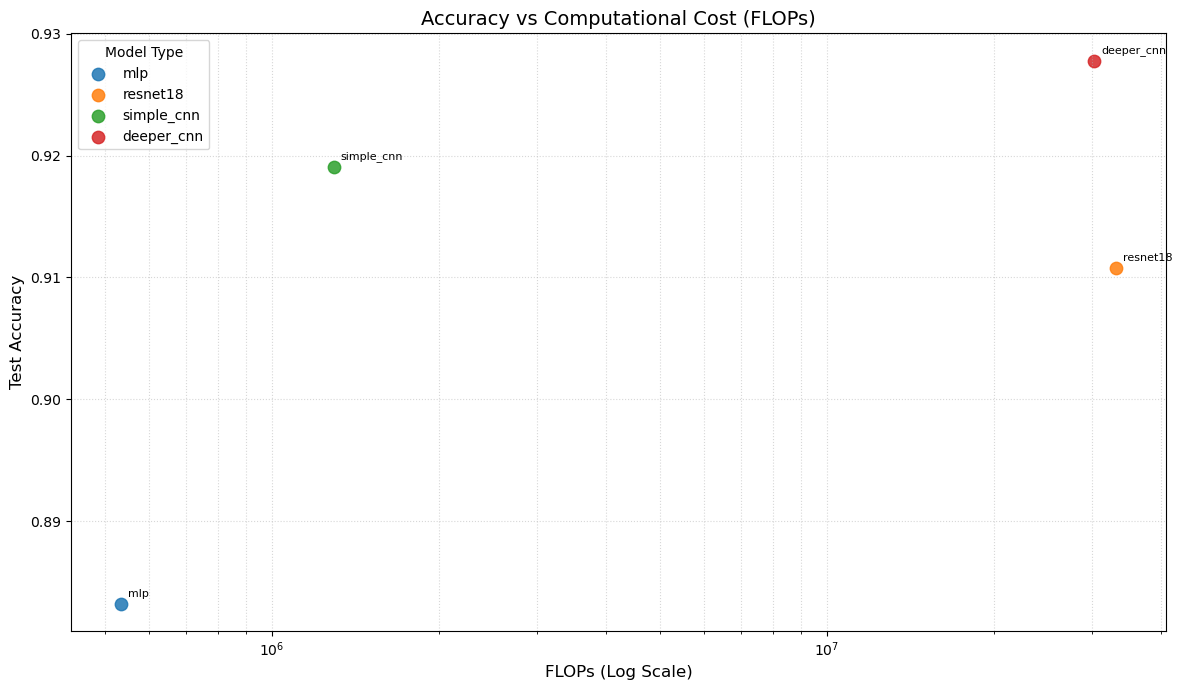

<Figure size 640x480 with 0 Axes>

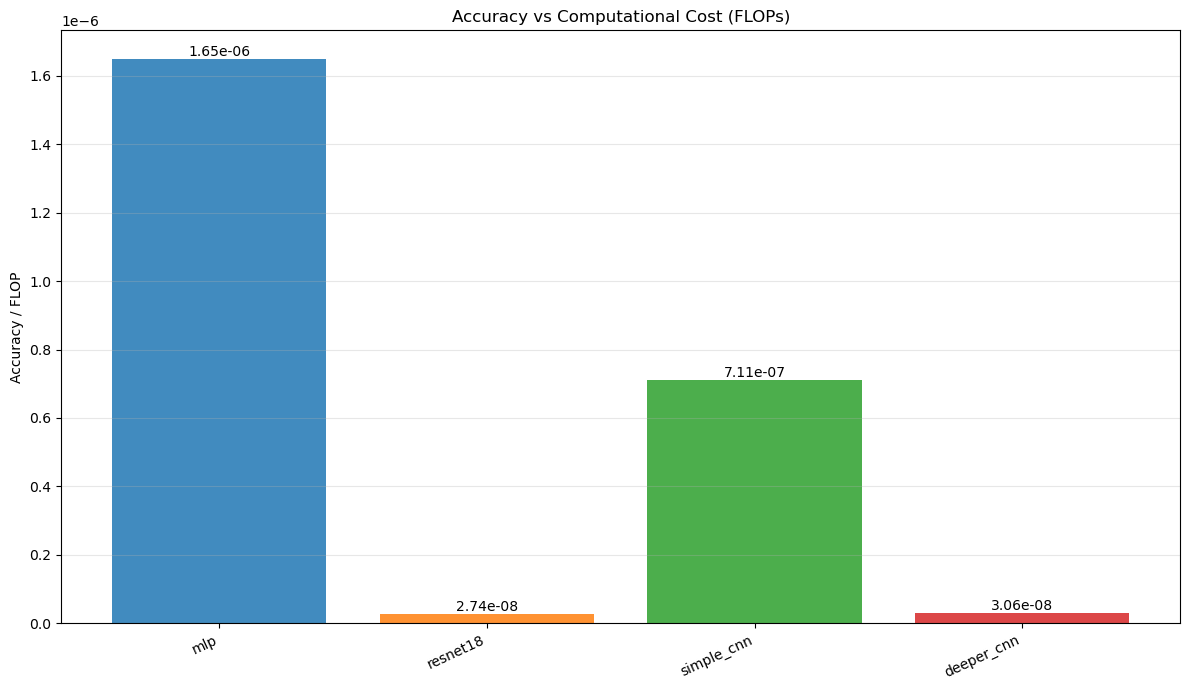

In [12]:
def plot_accuracy_vs_flops(df, mode="scatter"):
    """
    Scatter plot: Accuracy vs FLOPs
    Higher is better
    """

    plt.figure(figsize=(12, 7))

    if mode == "scatter":
        for _, row in df.iterrows():
            plt.scatter(
                row['flops'],
                row['accuracy'],
                label=row['model_type'],
                s=80,
                alpha=0.85
            )

            plt.annotate(
                row['model_type'],
                (row['flops'], row['accuracy']),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

        plt.xscale('log')
        plt.title("Accuracy vs Computational Cost (FLOPs)", fontsize=14)
        plt.xlabel("FLOPs (Log Scale)", fontsize=12)
        plt.ylabel("Test Accuracy", fontsize=12)
        plt.grid(True, which="both", ls=":", alpha=0.5)

        # If model names are unique, legend is fine like this
        plt.legend(title="Model Type")

        plt.tight_layout()
        plt.show()

    elif mode == "bar":
        # ---- Accuracy per FLOP ----
        for _, row in baselines.iterrows():
            model = row["model_type"]
            acc = row["accuracy"]
            flops = row["flops"]

            acc_per_flop = acc / flops

            plt.bar(model, acc_per_flop, alpha=0.85)

            plt.text(
                model,
                acc_per_flop,
                f"{acc_per_flop:.2e}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        plt.ylabel("Accuracy / FLOP")
        plt.title("Accuracy vs Computational Cost (FLOPs)")
        plt.xticks(rotation=25, ha="right")
        plt.grid(axis="y", alpha=0.3)

    else:
        raise ValueError("mode must be 'scatter' or 'bar'")

    plt.tight_layout()
    plt.show()
plot_accuracy_vs_flops(baselines)
plot_accuracy_vs_flops(baselines, "bar")

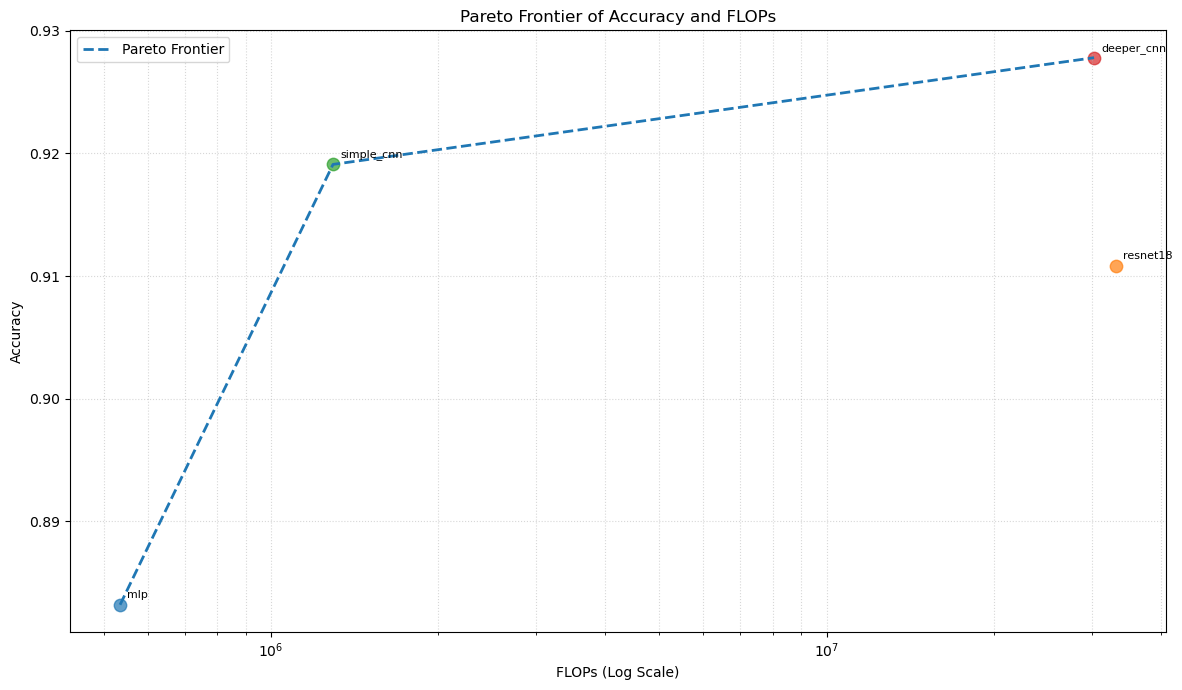

In [13]:
def get_pareto_frontier(df):
    """
    Returns Pareto-optimal points for (flops, accuracy)
    minimizing flops, maximizing accuracy
    """

    # Sort by FLOPs (ascending)
    sorted_df = df.sort_values("flops")

    pareto_points = []
    best_acc = -np.inf

    for _, row in sorted_df.iterrows():
        if row["accuracy"] > best_acc:
            pareto_points.append(row)
            best_acc = row["accuracy"]

    return np.array(pareto_points, dtype=object)

def plot_flops_accuracy_pareto(df):
    plt.figure(figsize=(12, 7))

    # ---- Scatter all models ----
    for _, row in df.iterrows():
        plt.scatter(
            row["flops"],
            row["accuracy"],
            s=80,
            alpha=0.7
        )
        plt.annotate(
            row["model_type"],
            (row["flops"], row["accuracy"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

    # ---- Pareto frontier ----
    pareto = df.sort_values("flops")

    pareto_x = []
    pareto_y = []
    best_acc = -np.inf

    for _, row in pareto.iterrows():
        if row["accuracy"] > best_acc:
            pareto_x.append(row["flops"])
            pareto_y.append(row["accuracy"])
            best_acc = row["accuracy"]

    plt.plot(
        pareto_x,
        pareto_y,
        linestyle="--",
        linewidth=2,
        label="Pareto Frontier"
    )

    plt.xscale("log")
    plt.xlabel("FLOPs (Log Scale)")
    plt.ylabel("Accuracy")
    plt.title("Pareto Frontier of Accuracy and FLOPs")
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_flops_accuracy_pareto(baselines)

# 4. Accuracy vs Time

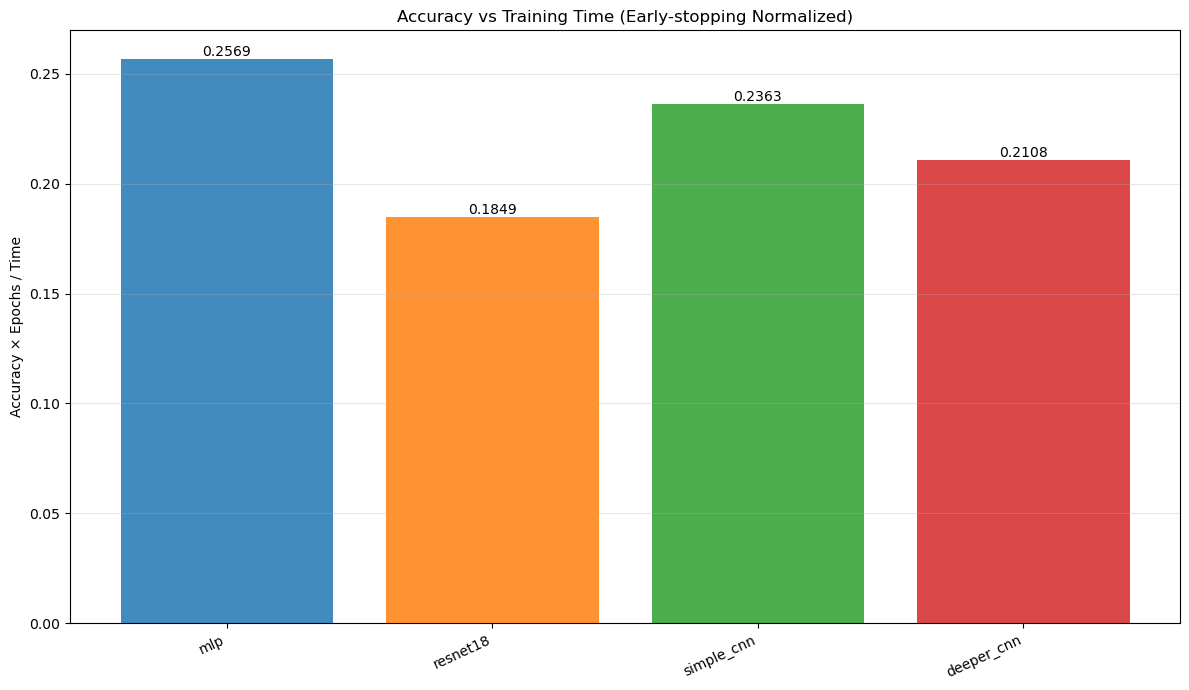

In [14]:
def plot_accuracy_per_epoch_second(df):
    """
    Plot: Accuracy per normalized training time (adjusted for epochs run)
    Higher is better
    """

    plt.figure(figsize=(12, 7))

    for _, row in df.iterrows():
        model = row["model_type"]
        acc = row["accuracy"]
        time = row["train_time_sec"]
        epochs = row["epochs_run"]

        # avoid division issues
        if time == 0 or epochs == 0:
            continue

        acc_per_time = acc * epochs / time

        plt.bar(model, acc_per_time, alpha=0.85)

        plt.text(
            model,
            acc_per_time,
            f"{acc_per_time:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.ylabel("Accuracy × Epochs / Time")
    plt.title("Accuracy vs Training Time (Early-stopping Normalized)")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_accuracy_per_epoch_second(baselines)

In [15]:
baselines = df[df["experiment_name"].str.contains("baseline")].sort_values(by="accuracy")
baselines

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id,N
23,2026-04-21T02:37:02.219750,baseline_mlp,mlp,adamw,0.001,128,0.3,none,he,0.8832,...,19,14,535818,535040,28.6,NVIDIA A100-SXM4-80GB,42,baseline_mlp.yaml,11980595,NaN
25,2026-04-21T02:41:05.832006,baseline_xgboost,xgboost,adamw,0.001,128,0.3,none,he,0.8911,...,100,-1,-1,-1,0.0,NVIDIA A100-SXM4-80GB,42,baseline_xgboost.yaml,11980597,NaN
38,2026-05-06T20:15:56.897467,baseline_resnet18,resnet18,adamw,0.001,128,0.3,none,he,0.9108,...,19,14,11175370,33184000,242.2,NVIDIA A100-SXM4-80GB,42,baseline_resnet18.yaml,12609947,NaN
24,2026-04-21T02:39:46.683263,baseline_simple_cnn,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,baseline_simple_cnn.yaml,11980596,NaN
22,2026-04-21T02:35:25.265091,baseline_deeper_cnn,deeper_cnn,adamw,0.001,128,0.3,none,he,0.9278,...,17,12,299114,30313984,163.7,NVIDIA A100-SXM4-80GB,42,baseline_deeper_cnn.yaml,11980594,NaN


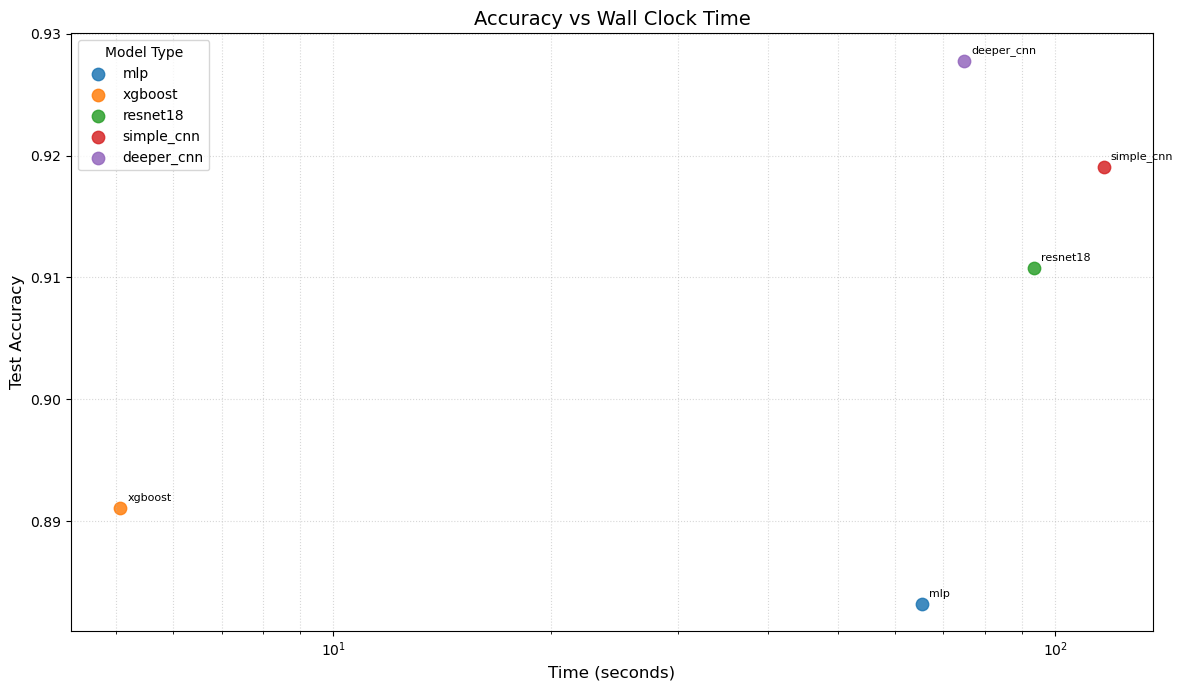

<Figure size 640x480 with 0 Axes>

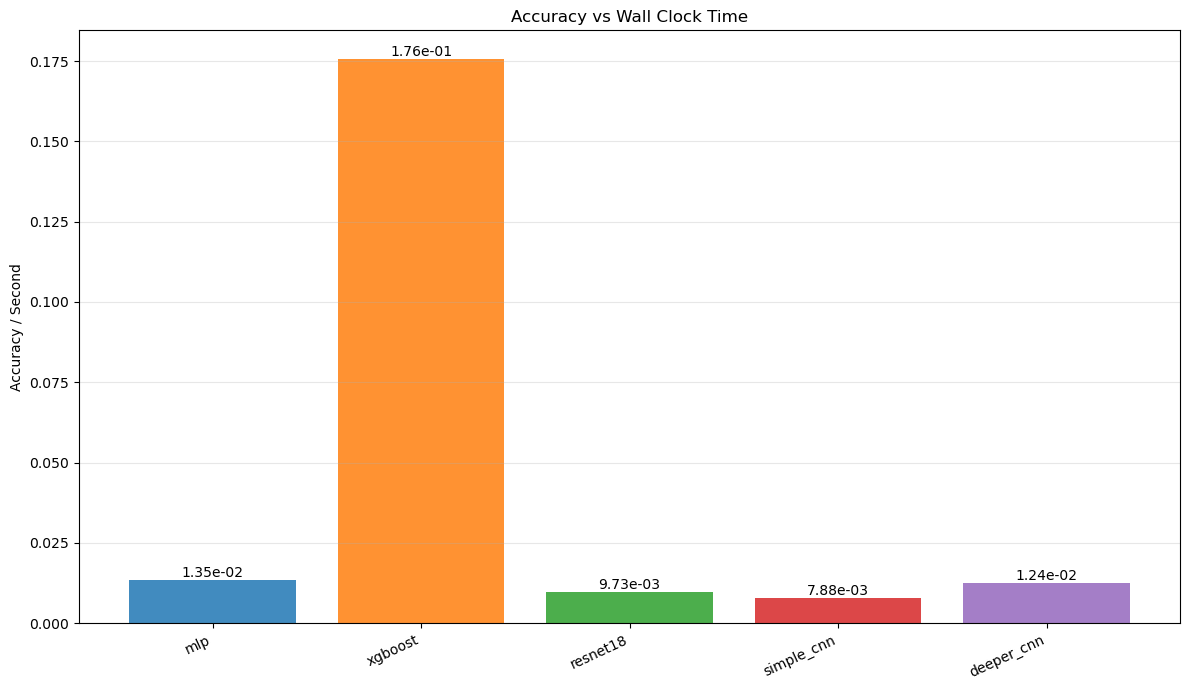

In [16]:
def plot_accuracy_vs_clock_time(df, mode="scatter"):
    """
    Scatter plot: Accuracy vs wall clock time
    NOTE: Early stoppage may affect these results
    Higher is better
    """

    plt.figure(figsize=(12, 7))

    if mode == "scatter":
        for _, row in df.iterrows():
            plt.scatter(
                row['train_time_sec'],
                row['accuracy'],
                label=row['model_type'],
                s=80,
                alpha=0.85
            )

            plt.annotate(
                row['model_type'],
                (row['train_time_sec'], row['accuracy']),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

        plt.xscale('log')
        plt.title("Accuracy vs Wall Clock Time", fontsize=14)
        plt.xlabel("Time (seconds)", fontsize=12)
        plt.ylabel("Test Accuracy", fontsize=12)
        plt.grid(True, which="both", ls=":", alpha=0.5)

        # If model names are unique, legend is fine like this
        plt.legend(title="Model Type")

        plt.tight_layout()
        plt.show()

    elif mode == "bar":
        # ---- Accuracy per FLOP ----
        for _, row in baselines.iterrows():
            model = row["model_type"]
            acc = row["accuracy"]
            train_time_sec = row["train_time_sec"]

            acc_per_sec = acc / train_time_sec

            plt.bar(model, acc_per_sec, alpha=0.85)

            plt.text(
                model,
                acc_per_sec,
                f"{acc_per_sec:.2e}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        plt.ylabel("Accuracy / Second")
        plt.title("Accuracy vs Wall Clock Time")
        plt.xticks(rotation=25, ha="right")
        plt.grid(axis="y", alpha=0.3)

    else:
        raise ValueError("mode must be 'scatter' or 'bar'")

    plt.tight_layout()
    plt.show()
plot_accuracy_vs_clock_time(baselines)
plot_accuracy_vs_clock_time(baselines, "bar")

# 5. Per Class Accuracy

In [17]:
baselines = df[df["experiment_name"].str.contains("baseline")].sort_values(by="accuracy")
baselines

,timestamp,experiment_name,model_type,optimizer,lr,batch_size,dropout,augmentation,initialization,accuracy,...,epochs_run,best_epoch,num_params,flops,gpu_mem_mb,device,seed,config_file,slurm_job_id,N
23,2026-04-21T02:37:02.219750,baseline_mlp,mlp,adamw,0.001,128,0.3,none,he,0.8832,...,19,14,535818,535040,28.6,NVIDIA A100-SXM4-80GB,42,baseline_mlp.yaml,11980595,NaN
25,2026-04-21T02:41:05.832006,baseline_xgboost,xgboost,adamw,0.001,128,0.3,none,he,0.8911,...,100,-1,-1,-1,0.0,NVIDIA A100-SXM4-80GB,42,baseline_xgboost.yaml,11980597,NaN
38,2026-05-06T20:15:56.897467,baseline_resnet18,resnet18,adamw,0.001,128,0.3,none,he,0.9108,...,19,14,11175370,33184000,242.2,NVIDIA A100-SXM4-80GB,42,baseline_resnet18.yaml,12609947,NaN
24,2026-04-21T02:39:46.683263,baseline_simple_cnn,simple_cnn,adamw,0.001,128,0.3,none,he,0.9191,...,30,26,207018,1293312,50.1,NVIDIA A100-SXM4-80GB,42,baseline_simple_cnn.yaml,11980596,NaN
22,2026-04-21T02:35:25.265091,baseline_deeper_cnn,deeper_cnn,adamw,0.001,128,0.3,none,he,0.9278,...,17,12,299114,30313984,163.7,NVIDIA A100-SXM4-80GB,42,baseline_deeper_cnn.yaml,11980594,NaN


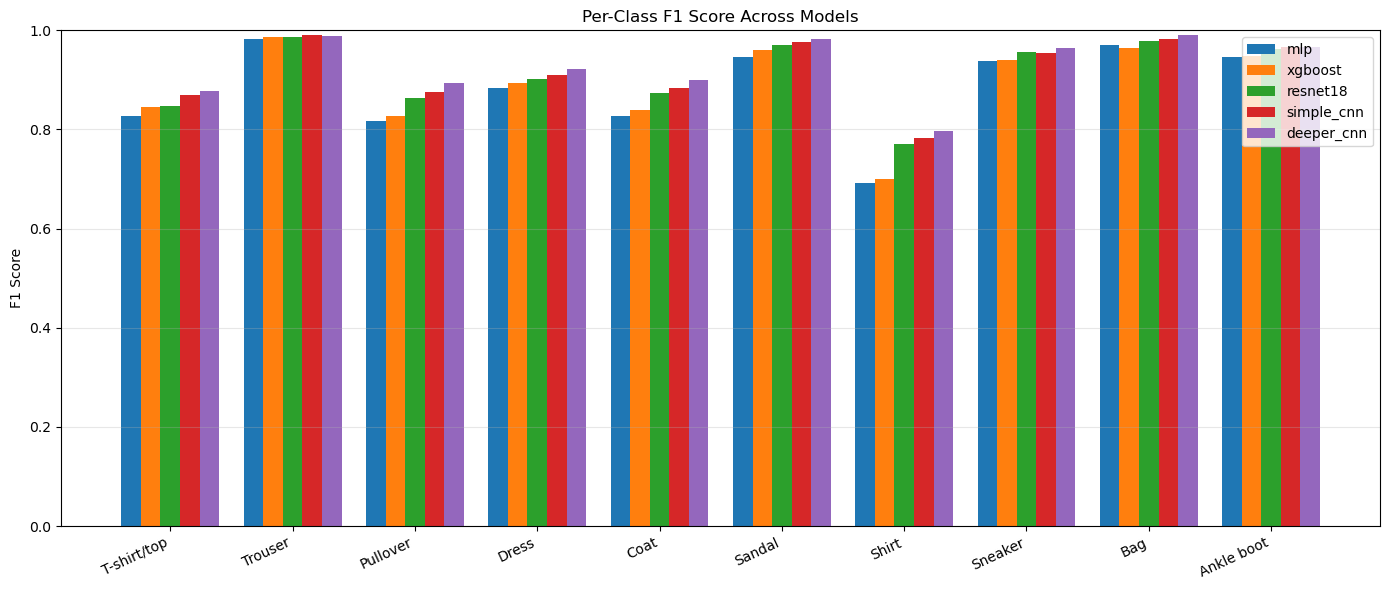

In [18]:
import ast
def plot_per_class_f1(baselines):

    class_names = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]

    models = baselines["model_type"].tolist()

    # FIX: convert strings → lists of floats
    f1_matrix = np.array([
        ast.literal_eval(row) for row in baselines["f1_per_class"]
    ])

    x = np.arange(len(class_names))
    width = 0.8 / len(models)

    plt.figure(figsize=(14, 6))

    for i, model in enumerate(models):
        plt.bar(
            x + i * width,
            f1_matrix[i],
            width=width,
            label=model
        )

    plt.xticks(
        x + width * (len(models) - 1) / 2,
        class_names,
        rotation=25,
        ha="right"
    )

    plt.ylim(0, 1.0)
    plt.ylabel("F1 Score")
    plt.title("Per-Class F1 Score Across Models")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_per_class_f1(baselines)

Trouser/Bag are easy (>0.96 F1), while Shirt/Pullover/Coat/T-shirt are hard (<0.83 F1). The hypothesis that CNNs will
disproportionately help these confusable classes is testable and interesting.

/tmp/ipykernel_292691/485749812.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(names, rotation=25, ha='right')


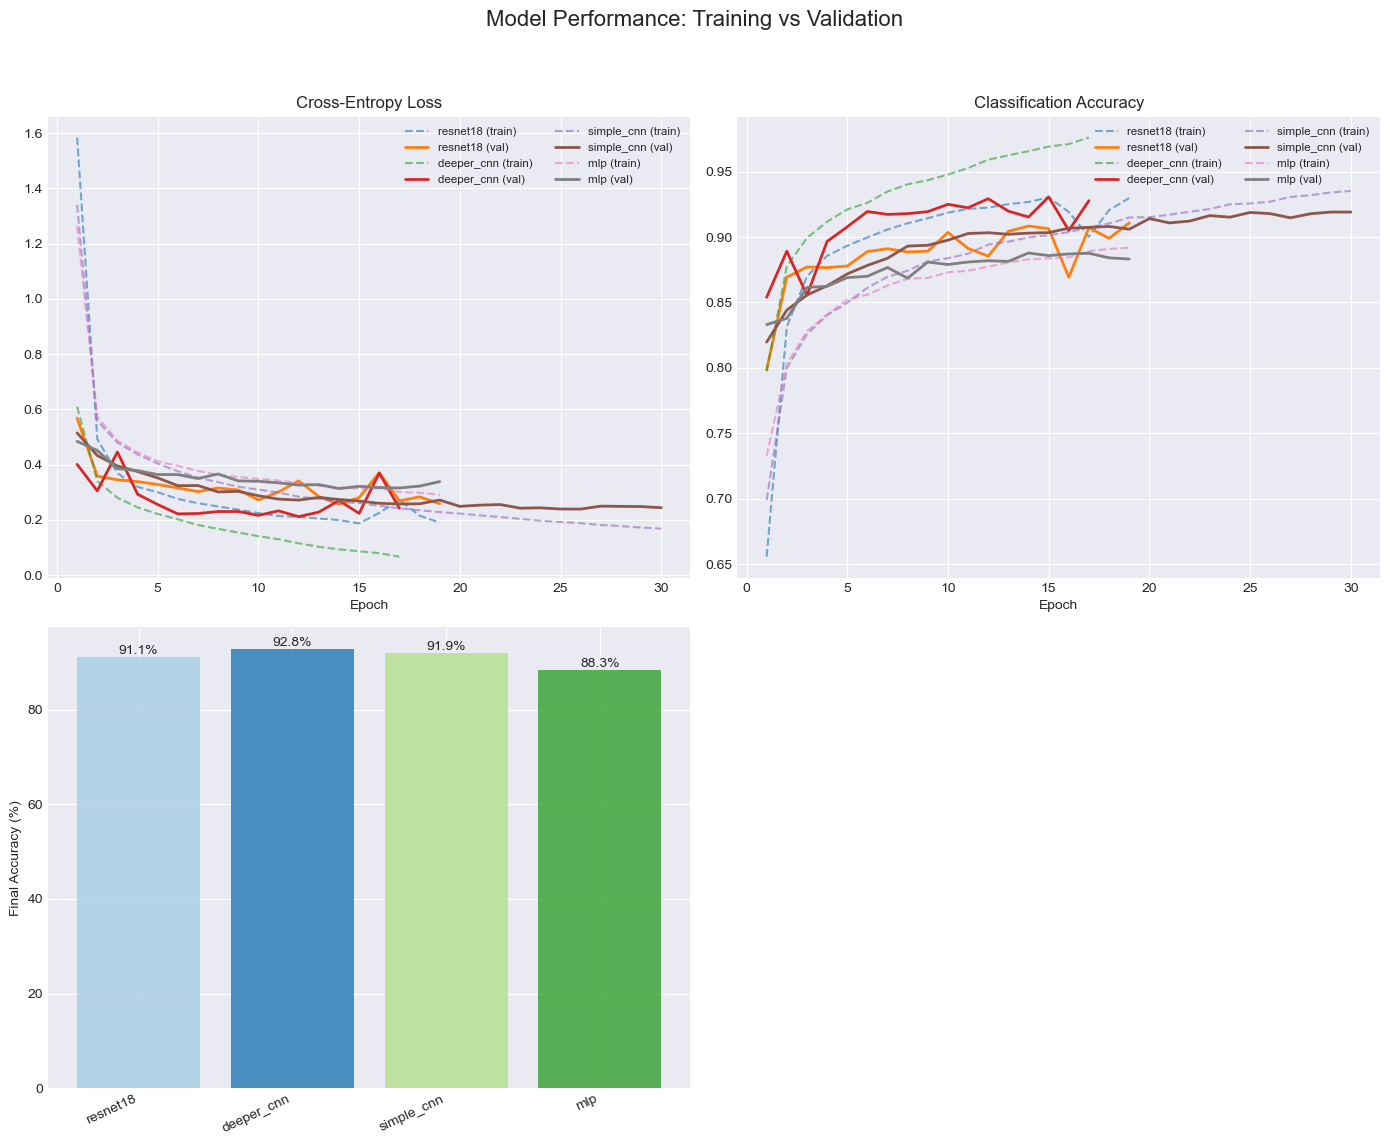

In [31]:
import os
import json
def load_baseline_results(directory="results/curves/"):
    """
    Loads all JSON files containing 'baseline' in the filename and cleans model names.
    """
    results = {}
    
    if not os.path.exists(directory):
        print(f"Directory {directory} not found.")
        return results

    for filename in os.listdir(directory):
        if "baseline" in filename and filename.endswith(".json"):
            filepath = os.path.join(directory, filename)
            
            with open(filepath, 'r') as f:
                data = json.load(f)
                
                # --- NAME TWEAKING LOGIC ---
                # 1. Remove '.json'
                # 2. Replace 'baseline_' with an empty string
                # 3. Optional: replace underscores with spaces or uppercase for better look
                clean_name = filename.replace(".json", "").replace("baseline_", "")
                
                results[clean_name] = {
                    "history": data,
                    "final_val_acc": data["val_acc"][-1]
                }
    return results

def visualize_training_results(results):
    if not results:
        print("No results found.")
        return

    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Model Performance: Training vs Validation', fontsize=16)

    # 1. Loss curves (Both Train and Val)
    ax_loss = axes[0, 0]
    # 2. Accuracy curves (Both Train and Val)
    ax_acc = axes[0, 1]

    for name, data in results.items():
        h = data['history']
        epochs = range(1, len(h['train_loss']) + 1)
        
        # --- LOSS PLOT ---
        # We use the clean 'name' (e.g., MLP) and append the type
        ax_loss.plot(epochs, h['train_loss'], '--', label=f'{name} (train)', alpha=0.6)
        ax_loss.plot(epochs, h['val_loss'], '-', label=f'{name} (val)', linewidth=2)
        
        # --- ACCURACY PLOT ---
        ax_acc.plot(epochs, h['train_acc'], '--', label=f'{name} (train)', alpha=0.6)
        ax_acc.plot(epochs, h['val_acc'], '-', label=f'{name} (val)', linewidth=2)

    ax_loss.set_title('Cross-Entropy Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.legend(fontsize='small', ncol=2) # ncol=2 helps if you have many models

    ax_acc.set_title('Classification Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend(fontsize='small', ncol=2)

    # 3. Final performance comparison (Bar Chart)
    ax_bar = axes[1, 0]
    names = list(results.keys())
    val_accs = [results[n]['final_val_acc'] * 100 for n in names]

    bars = ax_bar.bar(names, val_accs, color=plt.cm.Paired(range(len(names))), alpha=0.8)
    ax_bar.set_ylabel('Final Accuracy (%)')
    ax_bar.set_xticklabels(names, rotation=25, ha='right')
    ax_bar.bar_label(bars, fmt='%.1f%%')

    # Hide the 4th subplot
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execution
baseline_data = load_baseline_results("../results/curves/")
visualize_training_results(baseline_data)